In [21]:
import h5py
import numpy as np
import pandas as pd

import os
import torch
import pandas as pd
from skimage import io, transform
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, Subset
import torch.optim as optim

import torch.nn as nn
import torch.nn.functional as F
import math

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [2]:
!curl https://zenodo.org/records/2603256/files/test.h5?download=1 -o toptag.h5

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  331M  100  331M    0     0  13.3M      0  0:00:24  0:00:24 --:--:-- 15.8M


In [5]:
fileIN = "toptag.h5"
f = h5py.File(fileIN)
# and see what it contains
print(list(f.keys()))

['table']


In [7]:
df = pd.read_hdf(fileIN, 'table')
df

,E_0,PX_0,PY_0,PZ_0,E_1,PX_1,PY_1,PZ_1,E_2,PX_2,...,E_199,PX_199,PY_199,PZ_199,truthE,truthPX,truthPY,truthPZ,ttv,is_signal_new
436,218.364243,-172.341858,110.129105,-76.503624,153.661118,-111.320465,93.167969,-50.390713,76.708054,-56.523701,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1,0
440,122.238762,26.738468,-91.613998,76.382225,121.227135,17.644758,-93.015450,75.715302,90.420105,21.377417,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1,0
441,383.772308,-97.906456,79.640709,-362.426361,200.625992,-54.921326,37.994343,-189.184753,123.247223,-33.828953,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1,0
444,132.492752,-77.763947,-87.322601,-62.304600,83.946594,-49.450481,-53.823605,-41.288010,28.072624,-19.964916,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1,0
445,730.786987,-209.120010,-193.454315,-672.973877,225.477325,-75.363350,-66.226990,-201.926651,217.040192,-63.698189,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,169.716614,-122.102844,36.656090,112.031059,112.158615,-80.692657,24.224476,74.036636,86.687820,-60.876274,...,0.0,0.0,0.0,0.0,832.899963,-572.147461,249.778381,524.242310,1,1
822,287.591492,-81.565056,-140.493576,237.313202,160.357544,-34.246628,-88.843933,129.028931,105.006508,-30.313942,...,0.0,0.0,0.0,0.0,1014.205322,-213.806396,-476.465851,852.417358,1,1
824,91.996681,60.538616,-63.476665,27.734055,93.122139,60.690456,-61.697636,34.377369,67.617706,33.402180,...,0.0,0.0,0.0,0.0,659.905701,419.718506,-414.999115,239.802658,1,1
825,132.474686,35.062359,125.736656,22.593466,61.466259,7.588309,55.307018,25.722607,53.369095,17.563345,...,0.0,0.0,0.0,0.0,659.797302,39.736858,593.325745,230.296585,1,1


In [8]:
# each row of the dataframe is a jet, each constituient is a particle, the only features are the four momentum
# Converting dataframe into a usable dataset for a transformer model

class JetDataset(Dataset):

    def __init__(self, df):

        self.jets = list()
        self.labels = list()
        for index, row in df.iterrows():

            tensor = torch.tensor(row.values, dtype=torch.float)
            self.jets.append(tensor[:-6].reshape(-1, 4))
            self.labels.append(tensor[-1].item())

    def __len__(self):
        return len(self.jets)

    def __getitem__(self, index):
        return self.jets[index], self.labels[index]


In [9]:
dataset = JetDataset(df)

In [47]:
class MAB(nn.Module):
    def __init__(self, dim_Q, dim_K, dim_V, num_heads, bias = True, ln=False):
        super(MAB, self).__init__()
        self.dim_V = dim_V
        self.num_heads = num_heads
        self.fc_q = nn.Linear(dim_Q, dim_V, bias = bias)
        self.fc_k = nn.Linear(dim_K, dim_V, bias = bias)
        self.fc_v = nn.Linear(dim_K, dim_V, bias = bias)
        if ln:
            self.ln0 = nn.LayerNorm(dim_V)
            self.ln1 = nn.LayerNorm(dim_V)
        self.fc_o = nn.Linear(dim_V, dim_V, bias = bias)

    def forward(self, Q, K):
        Q = self.fc_q(Q)
        K, V = self.fc_k(K), self.fc_v(K)

        dim_split = self.dim_V // self.num_heads
        Q_ = torch.cat(Q.split(dim_split, 2), 0)
        K_ = torch.cat(K.split(dim_split, 2), 0)
        V_ = torch.cat(V.split(dim_split, 2), 0)

        A = torch.softmax(Q_.bmm(K_.transpose(1,2))/math.sqrt(self.dim_V), 2)
        O = torch.cat((Q_ + A.bmm(V_)).split(Q.size(0), 0), 2)
        O = O if getattr(self, 'ln0', None) is None else self.ln0(O)
        O = O + F.relu(self.fc_o(O))
        O = O if getattr(self, 'ln1', None) is None else self.ln1(O)
        return O

class SAB(nn.Module):
    def __init__(self, dim_in, dim_out, num_heads, ln=False, bias=True,):
        super(SAB, self).__init__()
        self.mab = MAB(dim_in, dim_in, dim_out, num_heads, ln=ln, bias=bias)

    def forward(self, X):
        return self.mab(X, X)

# A one layer transformer (one self attention block)
class SetTransformer(nn.Module):
    def __init__(self, dim_input, dim_output, num_particles_per_jet, dim_hidden=64, num_heads=8, bias=True, ln=False):
        super(SetTransformer, self).__init__()
        self.enc = nn.Sequential(
                SAB(dim_input, dim_hidden, num_heads, ln=ln, bias=bias),
              )
        self.pool = nn.AvgPool1d(num_particles_per_jet)
        self.norm = nn.BatchNorm1d(dim_hidden)
        self.fc = nn.Sequential(
            nn.Linear(dim_hidden, 64, bias = bias),
            nn.LeakyReLU(),
            nn.Linear(64,16, bias = bias),
            nn.LeakyReLU(),
            nn.Linear(16,dim_output, bias = bias),
        )

    def forward(self, X):
        X_ = self.pool(self.enc(X).transpose(1, 2)).squeeze(dim=-1)
        X_ = self.fc(self.norm(X_))
        return X_

In [48]:
torch.cuda.is_available()

False

In [54]:
# define model, dataloaders, optimizers, etc.

dim_in = 4
dim_output = 1
num_particles_per_jet = 200
num_heads = 4
bias = True
model = SetTransformer(dim_in, dim_output, num_particles_per_jet, num_heads = num_heads, bias = bias)


dataset_size = 10000  # use a smaller number of datapoints for debugging

subset_indices_train = list(range(dataset_size))
subset_indices_val = list(range(dataset_size,dataset_size + int(dataset_size*0.2)))
subset_indices_test = list(range(dataset_size + int(dataset_size*0.2), dataset_size + 2*int(dataset_size*0.2)))

train_subset = Subset(dataset, subset_indices_train)
val_subset = Subset(dataset, subset_indices_val)
test_subset = Subset(dataset, subset_indices_test)

train_dataloader = DataLoader(train_subset, batch_size=512, shuffle=True)
val_dataloader = DataLoader(val_subset, batch_size=512, shuffle=True)
test_dataloader = DataLoader(test_subset, batch_size=512, shuffle=True)

optimizer = optim.Adam(model.parameters(), lr=0.0001)

m = nn.Sigmoid()
mm = nn.BCELoss()

In [62]:
# training loop

epochs = 100

for epoch in range(epochs):

    losses = []

    model.train()
    for batch in iter(train_dataloader):

        X, y = batch

        output = model(X).squeeze(dim=1).to(torch.float64)

        loss = mm(m(output), y)

        losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # print(f"Epoch {epoch} batch loss {loss}")

    print(f"Epoch {epoch}, train loss {sum(losses)/len(losses)}")

    model.eval()
    val_losses = []
    with torch.no_grad():

      for batch in iter(val_dataloader):

        X, y = batch

        output = model(X).squeeze(dim=1).to(torch.float64)

        loss = mm(m(output), y)

        val_losses.append(loss.item())

    print(f"Epoch {epoch}, val loss {sum(val_losses)/len(val_losses)}")


Epoch 0, train loss 0.6757879897759402
Epoch 0, val loss 0.676087301861937
Epoch 1, train loss 0.6695764831473018
Epoch 1, val loss 0.6695256659812109
Epoch 2, train loss 0.6629993666289931
Epoch 2, val loss 0.6635499119011039
Epoch 3, train loss 0.6572069543901733
Epoch 3, val loss 0.6574291264292876
Epoch 4, train loss 0.6518288882144
Epoch 4, val loss 0.6519876277367869
Epoch 5, train loss 0.6467420109098053
Epoch 5, val loss 0.6460419102165078
Epoch 6, train loss 0.6416915785104407
Epoch 6, val loss 0.6405577282241188
Epoch 7, train loss 0.6383201312501758
Epoch 7, val loss 0.6369709094743208


KeyboardInterrupt: 

Test set loss: 0.632846356475329
Test accuracy: 0.5035


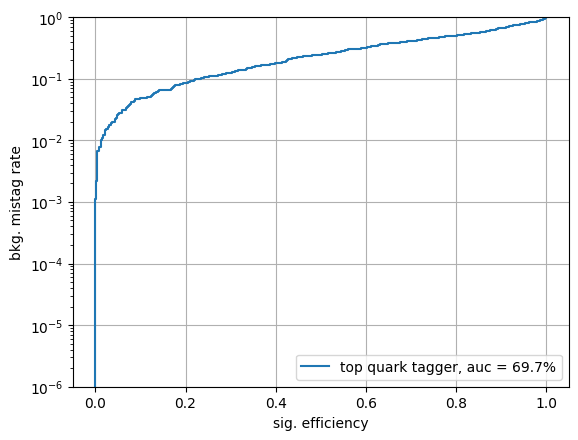

In [63]:
# testing on test set

model.eval()

test_losses = []
test_logits = []
test_labels_true = []
test_num_correct = 0
with torch.no_grad():

  for batch in iter(test_dataloader):

    X, y = batch

    output = model(X).squeeze(dim=1).to(torch.float64)

    predicted_labels = (output >= 0.5)

    loss = mm(m(output), y)

    test_labels_true.extend(list(y.to(torch.long).detach().numpy()))
    test_logits.extend(list(output.detach().numpy()))
    test_losses.append(loss.item())
    test_num_correct += torch.sum(y == predicted_labels).item()

print(f"Test set loss: {sum(test_losses)/len(test_losses)}")
print(f"Test accuracy: {test_num_correct / len(subset_indices_test)}")

import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import roc_curve, auc

df = pd.DataFrame()
fpr = {}
tpr = {}
auc1 = {}

plt.figure()

fpr, tpr, threshold = roc_curve(np.array(test_labels_true), np.array(test_logits))

auc1 = auc(fpr, tpr)

plt.plot(tpr,fpr,label='%s tagger, auc = %.1f%%'%("top quark",auc1*100.))

plt.semilogy()
plt.xlabel("sig. efficiency")
plt.ylabel("bkg. mistag rate")
plt.ylim(0.000001,1)
plt.grid(True)
plt.legend(loc='lower right')
plt.show()
